Mounted at /content/drive
Libraries loaded successfully.
Predictions loaded: (1076, 7)
Columns: ['actual', 'arima', 'arimax', 'lstm', 'gru', 'xgboost', 'garch_vol']
Date range: 2022-02-14 to 2026-04-15
              actual     arima    arimax      lstm       gru   xgboost  \
Date                                                                     
2022-02-14 -0.000198  0.000199 -0.000027  0.000028 -0.025253  0.000039   
2022-02-15 -0.001137  0.000120  0.000216  0.000015 -0.025592  0.000077   
2022-02-16  0.002026  0.000195 -0.000214 -0.000018 -0.027442  0.000122   
2022-02-17 -0.000568  0.000123 -0.000094 -0.000026 -0.027131  0.000054   
2022-02-18 -0.000074  0.000191  0.000149 -0.000021 -0.024651  0.000050   

            garch_vol  
Date                   
2022-02-14   0.005779  
2022-02-15   0.005817  
2022-02-16   0.005854  
2022-02-17   0.005891  
2022-02-18   0.005927  

HYBRID ENSEMBLE - WEIGHTED AVERAGE

Ensemble weights (inverse RMSE):
  arima       : 0.2677 (26.8%)
  xgboost 

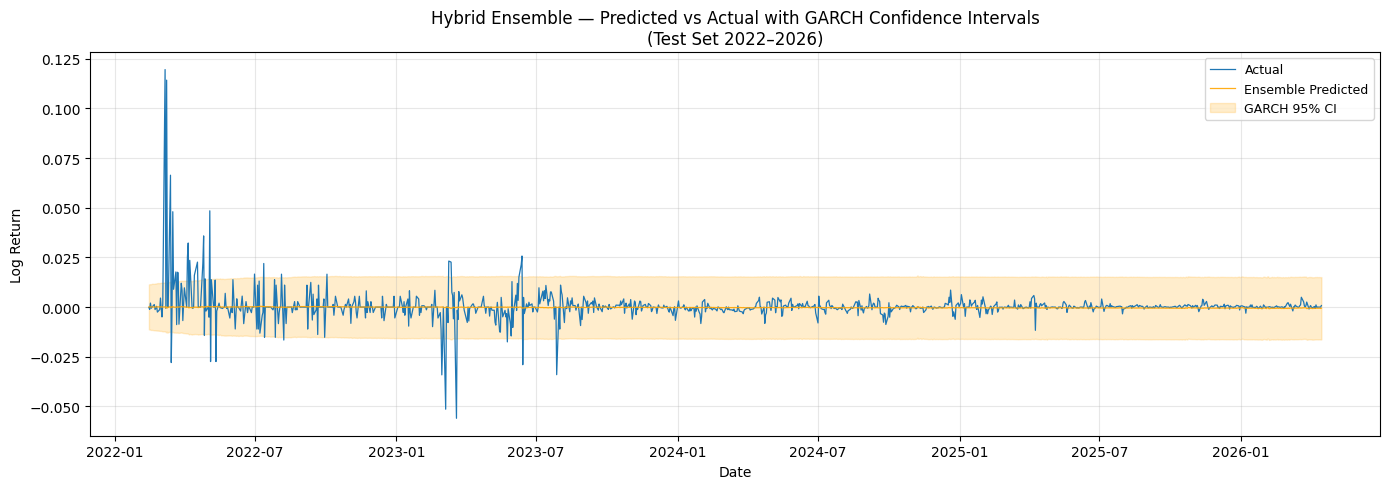


ABLATION STUDY — GOLD FEATURE CONTRIBUTION

───────────────────────────────────────────────────────
  With gold features
───────────────────────────────────────────────────────
  RMSE : 0.008065
  MAE  : 0.003040
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  Without gold features (ARIMA only)
───────────────────────────────────────────────────────
  RMSE : 0.008046
  MAE  : 0.002911
───────────────────────────────────────────────────────

Gold feature contribution:
  RMSE improvement: -0.24%
  MAE improvement:  -4.43%
  Gold features did NOT improve linear performance
  (Consistent with non-linear relationship — see Section 4.4.4)

FULL MODEL COMPARISON — ALL MODELS AND ENSEMBLES
                            model     rmse      mae       type
                            ARIMA 0.007943 0.002872 Individual
                       GARCH(1,1) 0.007943 0.002872 Individual
                          XGBoost 0.007960 0.002923 

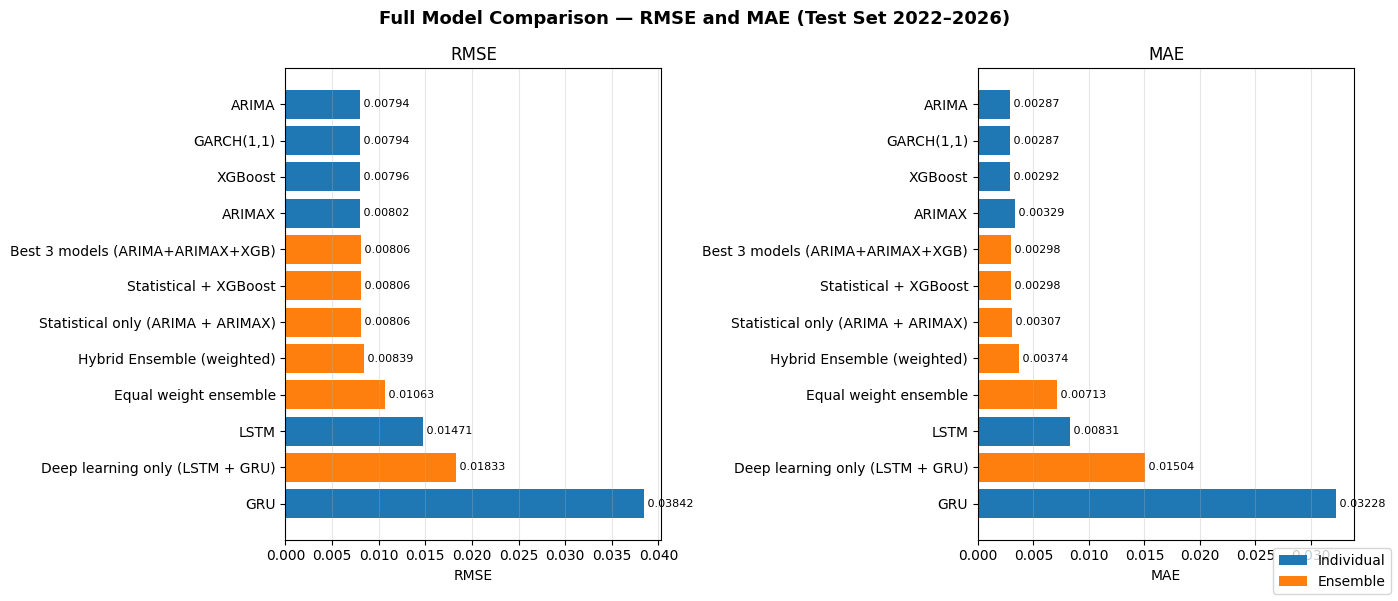

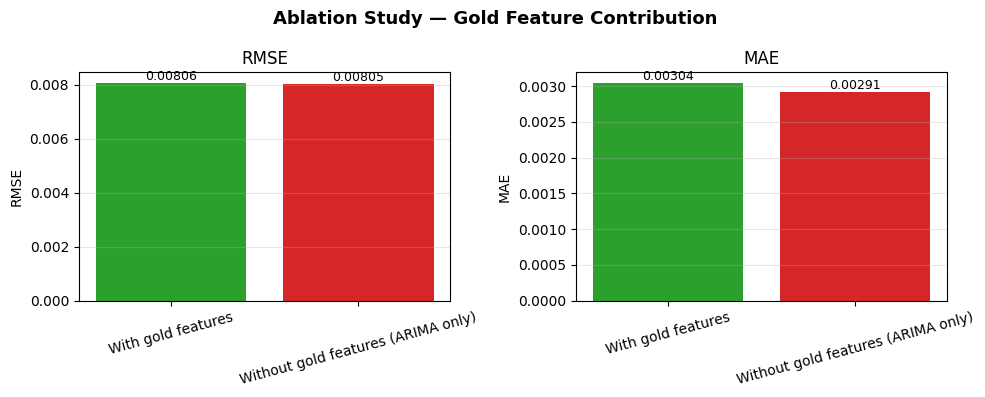

CHAPTER 7 COMPLETE


In [ ]:
!pip install pmdarima arch xgboost scikit-learn tensorflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# STEP 1: LOAD ALL PREDICTIONS FROM CHAPTER 6

preds_df = pd.read_csv(
    '/content/drive/MyDrive/MSc_Project/outputs/06_all_predictions.csv',
    index_col=0,
    parse_dates=True
)

print(f"Predictions loaded: {preds_df.shape}")
print(f"Columns: {preds_df.columns.tolist()}")
print(f"Date range: {preds_df.index.min().date()} to {preds_df.index.max().date()}")
print(preds_df.head())

actual    = preds_df['actual'].values
arima_p   = preds_df['arima'].values
arimax_p  = preds_df['arimax'].values
lstm_p    = preds_df['lstm'].values
gru_p     = preds_df['gru'].values
xgb_p     = preds_df['xgboost'].values
garch_vol = preds_df['garch_vol'].values

# STEP 2: EVALUATION FUNCTION

def evaluate(actual, predicted, model_name):
  #converts both arrays into a simple flat of numbers, ensures both are in the same shape before comparing them
    actual    = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mae  = np.mean(np.abs(actual - predicted))
    print(f"\n{'─'*55}")
    print(f"  {model_name}")
    print(f"{'─'*55}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  MAE  : {mae:.6f}")
    print(f"{'─'*55}")
    return {'model': model_name, 'rmse': round(rmse,6), 'mae': round(mae,6)}

#create an empty scoreboard list
results = []

# STEP 3: HYBRID ENSEMBLE - WEIGHTED AVERAGE
# Strategy: assign weights to each model based on their individual RMSE
# Better models (lower RMSE) get higher weights
# Weight = (1/RMSE) / sum(1/RMSE for all models)

print("\n" + "="*60)
print("HYBRID ENSEMBLE - WEIGHTED AVERAGE")
print("="*60)

# Individual RMSE from Chapter 6 results
rmse_scores = {
    'arima':   0.007943,
    'arimax':  0.008019,
    'xgboost': 0.007960,
    'lstm':    0.014709,
    'gru':     0.038416,
}

# Inverse RMSE weights - better models get higher weight
inv_rmse = {k: 1/v for k, v in rmse_scores.items()}
total    = sum(inv_rmse.values())
weights  = {k: v/total for k, v in inv_rmse.items()}

print("\nEnsemble weights (inverse RMSE):")
for model, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {model:<12}: {w:.4f} ({w*100:.1f}%)")

# Weighted ensemble prediction
ensemble_preds = (
    weights['arima']   * arima_p  +
    weights['arimax']  * arimax_p +
    weights['xgboost'] * xgb_p   +
    weights['lstm']    * lstm_p   +
    weights['gru']     * gru_p
)

res_ensemble = evaluate(actual, ensemble_preds, 'Hybrid Ensemble (weighted)')
results.append(res_ensemble)

# STEP 4: ENSEMBLE VARIANTS - COMPARE DIFFERENT COMBINATIONS

print("\n" + "="*60)
print("ENSEMBLE VARIANTS")
print("="*60)

# Variant 1: Statistical only (ARIMA + ARIMAX + GARCH)
stat_preds = (arima_p + arimax_p) / 2
res_stat = evaluate(actual, stat_preds, 'Statistical only (ARIMA + ARIMAX)')
results.append(res_stat)

# Variant 2: Deep learning only (LSTM + GRU)
dl_preds = (lstm_p + gru_p) / 2
res_dl = evaluate(actual, dl_preds, 'Deep learning only (LSTM + GRU)')
results.append(res_dl)

# Variant 3: Statistical + XGBoost (no deep learning)
stat_xgb_preds = (arima_p + arimax_p + xgb_p) / 3
res_stat_xgb = evaluate(actual, stat_xgb_preds, 'Statistical + XGBoost')
results.append(res_stat_xgb)

# Variant 4: Equal weight ensemble (all 5 models)
equal_preds = (arima_p + arimax_p + xgb_p + lstm_p + gru_p) / 5
res_equal = evaluate(actual, equal_preds, 'Equal weight ensemble')
results.append(res_equal)

# Variant 5: Best 3 models only (ARIMA + ARIMAX + XGBoost by RMSE)
best3_preds = (arima_p + arimax_p + xgb_p) / 3
res_best3 = evaluate(actual, best3_preds, 'Best 3 models (ARIMA+ARIMAX+XGB)')
results.append(res_best3)

# STEP 5: GARCH CONFIDENCE INTERVALS ON BEST ENSEMBLE

# Find best ensemble from results so far -lowest RMSE
results_df_temp = pd.DataFrame(results)
best_ensemble_name = results_df_temp.loc[results_df_temp['rmse'].idxmin(), 'model']
print(f"\nBest ensemble so far: {best_ensemble_name}")

# Use ARIMA + ARIMAX + XGBoost ensemble for confidence intervals
best_preds = (arima_p + arimax_p + xgb_p) / 3
# 1.96 is a standard statistics number, come frm the normal distribution
# and reprsent the boundary of a 95% confidence interval
upper_ci   = best_preds + 1.96 * garch_vol
lower_ci   = best_preds - 1.96 * garch_vol

#Note: grach_vol changes every day, on turbulent days it is larger
# so the band stretches wider, on clam days it is smaller
# so the band is narrow, this is what makes GARCH confidence intervals
# more useful than  fixed band.

# Plot ensemble predictions with GARCH confidence intervals
plt.figure(figsize=(14, 5))
plt.plot(preds_df.index, actual,     label='Actual',
         color='#1f77b4', linewidth=0.9)
plt.plot(preds_df.index, best_preds, label='Ensemble Predicted',
         color='orange', linewidth=0.9, alpha=0.9)
plt.fill_between(preds_df.index, lower_ci, upper_ci,
                 alpha=0.2, color='orange', label='GARCH 95% CI')
plt.title('Hybrid Ensemble — Predicted vs Actual with GARCH Confidence Intervals\n(Test Set 2022–2026)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/07a_ensemble_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()

# STEP 6: ABLATION STUDY - WITH vs WITHOUT GOLD FEATURES

print("\n" + "="*60)
print("ABLATION STUDY - GOLD FEATURE CONTRIBUTION")
print("="*60)

# The ablation study compares:
# WITH gold:    ARIMAX (gold exogenous) + XGBoost (gold features included)
# WITHOUT gold: ARIMA (no gold) only

# WITH gold ensemble
with_gold_preds    = (arimax_p + xgb_p) / 2
# WITHOUT gold ensemble
without_gold_preds = arima_p

res_with    = evaluate(actual, with_gold_preds,    'With gold features')
res_without = evaluate(actual, without_gold_preds, 'Without gold features (ARIMA only)')

ablation_results = [res_with, res_without]

# Calculate improvement
rmse_improvement = (res_without['rmse'] - res_with['rmse']) / res_without['rmse'] * 100
mae_improvement  = (res_without['mae']  - res_with['mae'])  / res_without['mae']  * 100

print(f"\nGold feature contribution:")
print(f"  RMSE improvement: {rmse_improvement:+.2f}%")
print(f"  MAE improvement:  {mae_improvement:+.2f}%")

if rmse_improvement > 0:
    print(f"  Gold features IMPROVED model performance")
elif rmse_improvement < 0:
    print(f"  Gold features did NOT improve linear performance")
    print(f"  (Consistent with non-linear relationship)")

# STEP 7: FULL RESULTS COMPARISON TABLE

print("\n" + "="*60)
print("FULL MODEL COMPARISON - ALL MODELS AND ENSEMBLES")
print("="*60)

# Individual model results from Chapter 6
individual = [
    {'model': 'ARIMA',      'rmse': 0.007943, 'mae': 0.002872, 'type': 'Individual'},
    {'model': 'GARCH(1,1)', 'rmse': 0.007943, 'mae': 0.002872, 'type': 'Individual'},
    {'model': 'XGBoost',    'rmse': 0.007960, 'mae': 0.002923, 'type': 'Individual'},
    {'model': 'ARIMAX',     'rmse': 0.008019, 'mae': 0.003293, 'type': 'Individual'},
    {'model': 'LSTM',       'rmse': 0.014709, 'mae': 0.008308, 'type': 'Individual'},
    {'model': 'GRU',        'rmse': 0.038416, 'mae': 0.032279, 'type': 'Individual'},
]

# Add ensemble results
ensemble_results = []
for r in results:
    ensemble_results.append({
        'model': r['model'],
        'rmse':  r['rmse'],
        'mae':   r['mae'],
        'type':  'Ensemble'
    })

all_results = individual + ensemble_results
all_df = pd.DataFrame(all_results).sort_values('rmse').reset_index(drop=True)

print(all_df.to_string(index=False))

all_df.to_csv(
    '/content/drive/MyDrive/MSc_Project/outputs/07_full_results.csv',
    index=False
)
print("\nFull results saved to: outputs/07_full_results.csv")

# STEP 8: VISUALISATIONS

# Plot 1: RMSE comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Full Model Comparison - RMSE and MAE (Test Set 2022–2026)',
             fontsize=13, fontweight='bold')

colors = ['#1f77b4' if t == 'Individual' else '#ff7f0e'
          for t in all_df['type']]

for ax, metric, label in zip(axes, ['rmse', 'mae'], ['RMSE', 'MAE']):
    bars = ax.barh(all_df['model'], all_df[metric], color=colors)
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, all_df[metric]):
      # add the exact number at the end of each bar
        ax.text(val, bar.get_y() + bar.get_height()/2,
                f' {val:.5f}', va='center', fontsize=8)
    ax.invert_yaxis() # puts the best model at the top rather than the bottom

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Individual'),
                   Patch(facecolor='#ff7f0e', label='Ensemble')]
fig.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/07b_full_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Ablation study bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Ablation Study - Gold Feature Contribution',
             fontsize=13, fontweight='bold')

ablation_df = pd.DataFrame(ablation_results)
#green -with gold, red-without gold features
colors_ab = ['#2ca02c', '#d62728']

for ax, metric, label in zip(axes, ['rmse', 'mae'], ['RMSE', 'MAE']):
    bars = ax.bar(ablation_df['model'], ablation_df[metric], color=colors_ab)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)#slighlty rotates the x-axis labels
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, ablation_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.5f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/07c_ablation_study.png',
            dpi=150, bbox_inches='tight')
plt.show()
